# Лабораторна робота №5 (MLP / Backprop) — Wine Quality (red)




## 0. Setup

In [ ]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report,
    roc_curve, auc, roc_auc_score
)

import matplotlib.pyplot as plt
sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 100
# reproducibility
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

## 1. Завантаження даних

In [27]:
def load_and_preprocess_data(test_size=0.15, val_size=0.15):
    '''
    Кроки:
    1) Завантажити CSV Wine Quality (red)
    2) Відокремити X та y
    3) Нормалізувати StandardScaler
    4) Поділ train/val/test
    5) Конвертувати в torch.Tensor
    '''
    url_red = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv"
    df = pd.read_csv(url_red, sep=";")  # UCI uses ';'

    X = df.drop(columns=["quality"]).values
    y_raw = df["quality"].values

    # Label encoding -> 0..K-1
    le = LabelEncoder()
    y = le.fit_transform(y_raw)
    class_names = [str(c) for c in le.classes_]

    # Split train vs temp (val+test)
    X_train, X_temp, y_train, y_temp = train_test_split(
        X, y, test_size=(test_size + val_size), random_state=SEED, stratify=y
    )

    # Split val vs test from temp
    val_ratio_in_temp = val_size / (test_size + val_size)
    X_val, X_test, y_val, y_test = train_test_split(
        X_temp, y_temp, test_size=(1 - val_ratio_in_temp),
        random_state=SEED, stratify=y_temp
    )

    # Normalize from train stats only
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_val   = scaler.transform(X_val)
    X_test  = scaler.transform(X_test)

    # to torch tensors
    X_train_t = torch.tensor(X_train, dtype=torch.float32)
    X_val_t   = torch.tensor(X_val, dtype=torch.float32)
    X_test_t  = torch.tensor(X_test, dtype=torch.float32)

    y_train_t = torch.tensor(y_train, dtype=torch.long)
    y_val_t   = torch.tensor(y_val, dtype=torch.long)
    y_test_t  = torch.tensor(y_test, dtype=torch.long)

    return X_train_t, y_train_t, X_val_t, y_val_t, X_test_t, y_test_t, class_names

X_train, y_train, X_val, y_val, X_test, y_test, class_names = load_and_preprocess_data()

print("Train:", X_train.shape, y_train.shape)
print("Val:  ", X_val.shape, y_val.shape)
print("Test: ", X_test.shape, y_test.shape)
print("Classes:", class_names)

Train: torch.Size([1119, 11]) torch.Size([1119])
Val:   torch.Size([240, 11]) torch.Size([240])
Test:  torch.Size([240, 11]) torch.Size([240])
Classes: ['3', '4', '5', '6', '7', '8']


## 2. Функції активації (forward + derivative)

In [28]:
class ActivationFunctions:
    @staticmethod
    def relu(x, derivative=False):
        if derivative:
            return (x > 0).float()
        return torch.clamp(x, min=0.0)

    @staticmethod
    def tanh(x, derivative=False):
        if derivative:
            return 1 - torch.tanh(x)**2
        return torch.tanh(x)

    @staticmethod
    def softmax(x):
        # stable softmax over rows (classes)
        x_shift = x - x.max(dim=0, keepdim=True).values
        exp_x = torch.exp(x_shift)
        return exp_x / exp_x.sum(dim=0, keepdim=True)

## 3. Функція втрат Cross-Entropy + похідна softmax+CE

In [29]:
class LossFunctions:
    @staticmethod
    def categorical_cross_entropy(y_pred, y_true, derivative=False):
        '''
        y_pred: (batch, num_classes) probabilities
        y_true: (batch,) integer labels
        '''
        eps = 1e-9
        batch_size = y_pred.shape[0]

        if derivative:
            # grad for logits in softmax+CE combo:
            # dZ = (y_pred - y_true_onehot) / batch
            grad = y_pred.clone()
            grad[range(batch_size), y_true] -= 1.0
            return grad / batch_size

        # forward loss
        correct_probs = y_pred[range(batch_size), y_true]
        loss = -torch.log(correct_probs + eps).mean()
        return loss

## 4. Custom MLP з нуля (без autograd)

In [33]:
class CustomMLP:
    def __init__(self, layer_sizes, activations, learning_rate=0.01):
        '''
        layer_sizes: [input, h1, h2, ..., output]
        activations: list like ["relu","tanh", ...] for hidden layers
        '''
        self.layer_sizes = layer_sizes
        self.activations = activations
        self.lr = learning_rate
        self.parameters = {}
        self._init_params()
    
    def predict_proba(self, X):
        """
        Повертає ймовірності для кожного класу
        forward() повертає (y_pred, cache), тому розпаковуємо
        """
        with torch.no_grad():  # Вимикаємо градієнти для інференсу
            y_pred, _ = self.forward(X)  # Розпаковуємо обидва значення
        return y_pred  # y_pred вже містить ймовірності після softmax
    
    
    def _init_params(self):
        for i in range(1, len(self.layer_sizes)):
            in_dim  = self.layer_sizes[i-1]
            out_dim = self.layer_sizes[i]
            # Xavier init
            limit = np.sqrt(6.0 / (in_dim + out_dim))
            W = torch.empty(out_dim, in_dim).uniform_(-limit, limit)
            b = torch.zeros(out_dim, 1)
            self.parameters[f"W{i}"] = W
            self.parameters[f"b{i}"] = b

    def _act(self, name, x, derivative=False):
        if name == "relu":
            return ActivationFunctions.relu(x, derivative=derivative)
        if name == "tanh":
            return ActivationFunctions.tanh(x, derivative=derivative)
        raise ValueError(f"Unknown activation {name}")

    def forward(self, X):
        '''
        X: (batch, features)
        cache stores A and Z in column-major form
        '''
        cache = {}
        A_prev = X.T  # (in_dim, batch)
        cache["A0"] = A_prev

        L = len(self.layer_sizes) - 1
        for i in range(1, L + 1):
            W = self.parameters[f"W{i}"]
            b = self.parameters[f"b{i}"]
            Z = W @ A_prev + b  # (out_dim, batch)
            cache[f"Z{i}"] = Z

            if i < L:
                act_name = self.activations[i-1]
                A = self._act(act_name, Z)
            else:
                A = ActivationFunctions.softmax(Z)

            cache[f"A{i}"] = A
            A_prev = A

        return cache[f"A{L}"].T, cache  # (batch, classes)

    def backward(self, y_pred, y_true, cache):
        '''
        y_pred: (batch, classes)
        y_true: (batch,)
        '''
        L = len(self.layer_sizes) - 1

        # dZ for output
        dZ = LossFunctions.categorical_cross_entropy(y_pred, y_true, derivative=True).T  # (classes, batch)

        for i in range(L, 0, -1):
            A_prev = cache[f"A{i-1}"]  # (prev_dim, batch)
            W = self.parameters[f"W{i}"]

            dW = dZ @ A_prev.T
            db = dZ.sum(dim=1, keepdim=True)

            # update
            self.parameters[f"W{i}"] -= self.lr * dW
            self.parameters[f"b{i}"] -= self.lr * db

            if i > 1:
                dA_prev = W.T @ dZ
                Z_prev = cache[f"Z{i-1}"]
                act_name = self.activations[i-2]
                dZ = dA_prev * self._act(act_name, Z_prev, derivative=True)

    def predict(self, X):
        y_pred, _ = self.forward(X)
        return torch.argmax(y_pred, dim=1)

    def fit(self, X_train, y_train, X_val, y_val, epochs=300, batch_size=64):
        history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

        n = X_train.shape[0]
        for ep in range(1, epochs + 1):
            idx = torch.randperm(n)
            X_sh = X_train[idx]
            y_sh = y_train[idx]

            for start in range(0, n, batch_size):
                end = start + batch_size
                xb = X_sh[start:end]
                yb = y_sh[start:end]

                y_pred, cache = self.forward(xb)
                self.backward(y_pred, yb, cache)

            with torch.no_grad():
                train_pred_probs, _ = self.forward(X_train)
                val_pred_probs, _   = self.forward(X_val)

                tr_loss = LossFunctions.categorical_cross_entropy(train_pred_probs, y_train)
                va_loss = LossFunctions.categorical_cross_entropy(val_pred_probs, y_val)

                tr_acc = (train_pred_probs.argmax(1) == y_train).float().mean()
                va_acc = (val_pred_probs.argmax(1) == y_val).float().mean()

            history["train_loss"].append(tr_loss.item())
            history["val_loss"].append(va_loss.item())
            history["train_acc"].append(tr_acc.item())
            history["val_acc"].append(va_acc.item())

            if ep % 50 == 0 or ep == 1:
                print(f"Epoch {ep:4d} | train loss {tr_loss:.4f} acc {tr_acc:.4f} | val loss {va_loss:.4f} acc {va_acc:.4f}")

        return history

## 5. Навчання Custom MLP

In [34]:
input_size = X_train.shape[1]
num_classes = len(class_names)

custom_model = CustomMLP(
    layer_sizes=[input_size, 64, 32, num_classes],
    activations=["relu", "tanh"],
    learning_rate=0.01
)

history_custom = custom_model.fit(X_train, y_train, X_val, y_val, epochs=400, batch_size=64)

Epoch    1 | train loss 1.6290 acc 0.3405 | val loss 1.6331 acc 0.3208
Epoch   50 | train loss 0.9448 acc 0.6247 | val loss 0.9814 acc 0.5917
Epoch  100 | train loss 0.8977 acc 0.6247 | val loss 0.9413 acc 0.6125
Epoch  150 | train loss 0.8670 acc 0.6416 | val loss 0.9253 acc 0.6167
Epoch  200 | train loss 0.8419 acc 0.6604 | val loss 0.9203 acc 0.6083
Epoch  250 | train loss 0.8192 acc 0.6676 | val loss 0.9190 acc 0.6125
Epoch  300 | train loss 0.7978 acc 0.6774 | val loss 0.9208 acc 0.6125
Epoch  350 | train loss 0.7773 acc 0.6828 | val loss 0.9265 acc 0.6250
Epoch  400 | train loss 0.7565 acc 0.6971 | val loss 0.9249 acc 0.6292


## 6. PyTorch MLP для порівняння

In [35]:
class PyTorchMLP(nn.Module):
    def __init__(self, input_size, hidden_sizes, output_size):
        super().__init__()
        layers = []
        prev = input_size
        for h in hidden_sizes:
            layers.append(nn.Linear(prev, h))
            layers.append(nn.ReLU())
            prev = h
        layers.append(nn.Linear(prev, output_size))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

def train_pytorch_model(model, X_train, y_train, X_val, y_val, epochs=400, lr=0.001):
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

    for ep in range(1, epochs + 1):
        model.train()
        optimizer.zero_grad()
        logits = model(X_train)
        loss = criterion(logits, y_train)
        loss.backward()
        optimizer.step()

        model.eval()
        with torch.no_grad():
            tr_logits = model(X_train)
            va_logits = model(X_val)

            tr_loss = criterion(tr_logits, y_train)
            va_loss = criterion(va_logits, y_val)

            tr_acc = (tr_logits.argmax(1) == y_train).float().mean()
            va_acc = (va_logits.argmax(1) == y_val).float().mean()

        history["train_loss"].append(tr_loss.item())
        history["val_loss"].append(va_loss.item())
        history["train_acc"].append(tr_acc.item())
        history["val_acc"].append(va_acc.item())

        if ep % 50 == 0 or ep == 1:
            print(f"[PT] Epoch {ep:4d} | train loss {tr_loss:.4f} acc {tr_acc:.4f} | val loss {va_loss:.4f} acc {va_acc:.4f}")

    return history

pt_model = PyTorchMLP(input_size, [64, 32], num_classes)
history_pt = train_pytorch_model(pt_model, X_train, y_train, X_val, y_val)

[PT] Epoch    1 | train loss 1.7485 acc 0.3843 | val loss 1.7535 acc 0.3542
[PT] Epoch   50 | train loss 1.0994 acc 0.5809 | val loss 1.1130 acc 0.5500
[PT] Epoch  100 | train loss 0.9595 acc 0.6122 | val loss 0.9875 acc 0.6000
[PT] Epoch  150 | train loss 0.9109 acc 0.6220 | val loss 0.9587 acc 0.6083
[PT] Epoch  200 | train loss 0.8664 acc 0.6425 | val loss 0.9469 acc 0.6208
[PT] Epoch  250 | train loss 0.8214 acc 0.6613 | val loss 0.9433 acc 0.6292
[PT] Epoch  300 | train loss 0.7743 acc 0.6863 | val loss 0.9451 acc 0.6417
[PT] Epoch  350 | train loss 0.7233 acc 0.7194 | val loss 0.9558 acc 0.6500
[PT] Epoch  400 | train loss 0.6717 acc 0.7382 | val loss 0.9824 acc 0.6458


## 7. Графіки навчання (loss/accuracy)

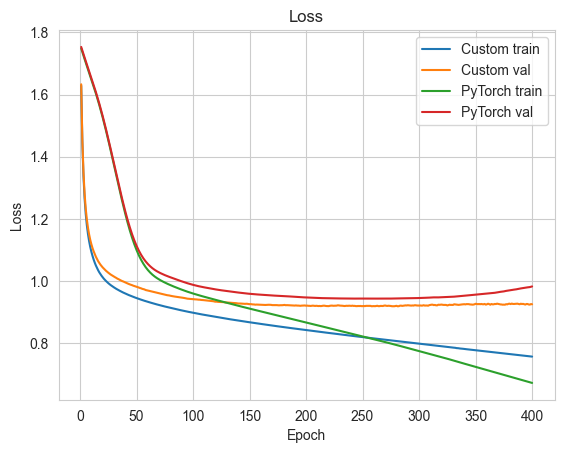

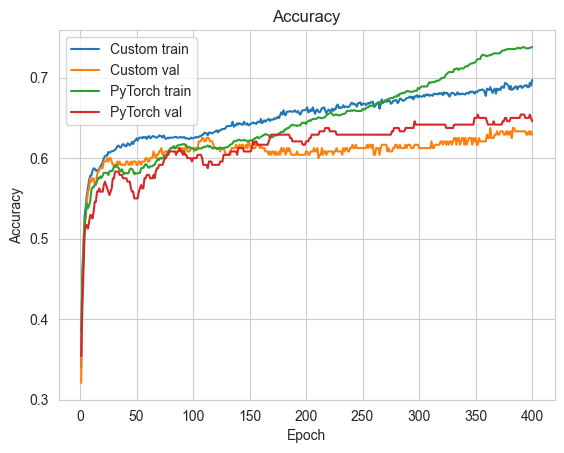

In [36]:
def plot_training_history(hc, hp):
    epochs = range(1, len(hc["train_loss"]) + 1)

    plt.figure()
    plt.plot(epochs, hc["train_loss"], label="Custom train")
    plt.plot(epochs, hc["val_loss"], label="Custom val")
    plt.plot(epochs, hp["train_loss"], label="PyTorch train")
    plt.plot(epochs, hp["val_loss"], label="PyTorch val")
    plt.title("Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.show()

    plt.figure()
    plt.plot(epochs, hc["train_acc"], label="Custom train")
    plt.plot(epochs, hc["val_acc"], label="Custom val")
    plt.plot(epochs, hp["train_acc"], label="PyTorch train")
    plt.plot(epochs, hp["val_acc"], label="PyTorch val")
    plt.title("Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.show()

plot_training_history(history_custom, history_pt)

## 8. Базові метрики

In [39]:
with torch.no_grad():
    y_pred_custom_proba = custom_model.predict_proba(X_test)  # ✅ Вже повертає тензор
    y_pred_custom = y_pred_custom_proba.argmax(1)

# PyTorch model predictions
pt_model.eval()
with torch.no_grad():
    y_pred_pt_proba = torch.softmax(pt_model(X_test), dim=1)
    y_pred_pt = y_pred_pt_proba.argmax(1)

# Конвертуємо в numpy для sklearn метрик
y_test_np = y_test.numpy()
y_pred_custom_np = y_pred_custom.numpy()
y_pred_pt_np = y_pred_pt.numpy()
y_pred_custom_proba_np = y_pred_custom_proba.numpy()
y_pred_pt_proba_np = y_pred_pt_proba.numpy()

n_classes = len(class_names)

print("="*70)
print("БАЗОВІ МЕТРИКИ ТОЧНОСТІ")
print("="*70)
print(f"Custom MLP accuracy:  {accuracy_score(y_test_np, y_pred_custom_np):.4f}")
print(f"PyTorch MLP accuracy: {accuracy_score(y_test_np, y_pred_pt_np):.4f}")
print(f"Різниця: {abs(accuracy_score(y_test_np, y_pred_custom_np) - accuracy_score(y_test_np, y_pred_pt_np)):.4f}")

БАЗОВІ МЕТРИКИ ТОЧНОСТІ
Custom MLP accuracy:  0.6125
PyTorch MLP accuracy: 0.5792
Різниця: 0.0333


2. CONFUSION MATRIX З НОРМАЛІЗАЦІЄЮ

## CONFUSION MATRIX З НОРМАЛІЗАЦІЄЮ

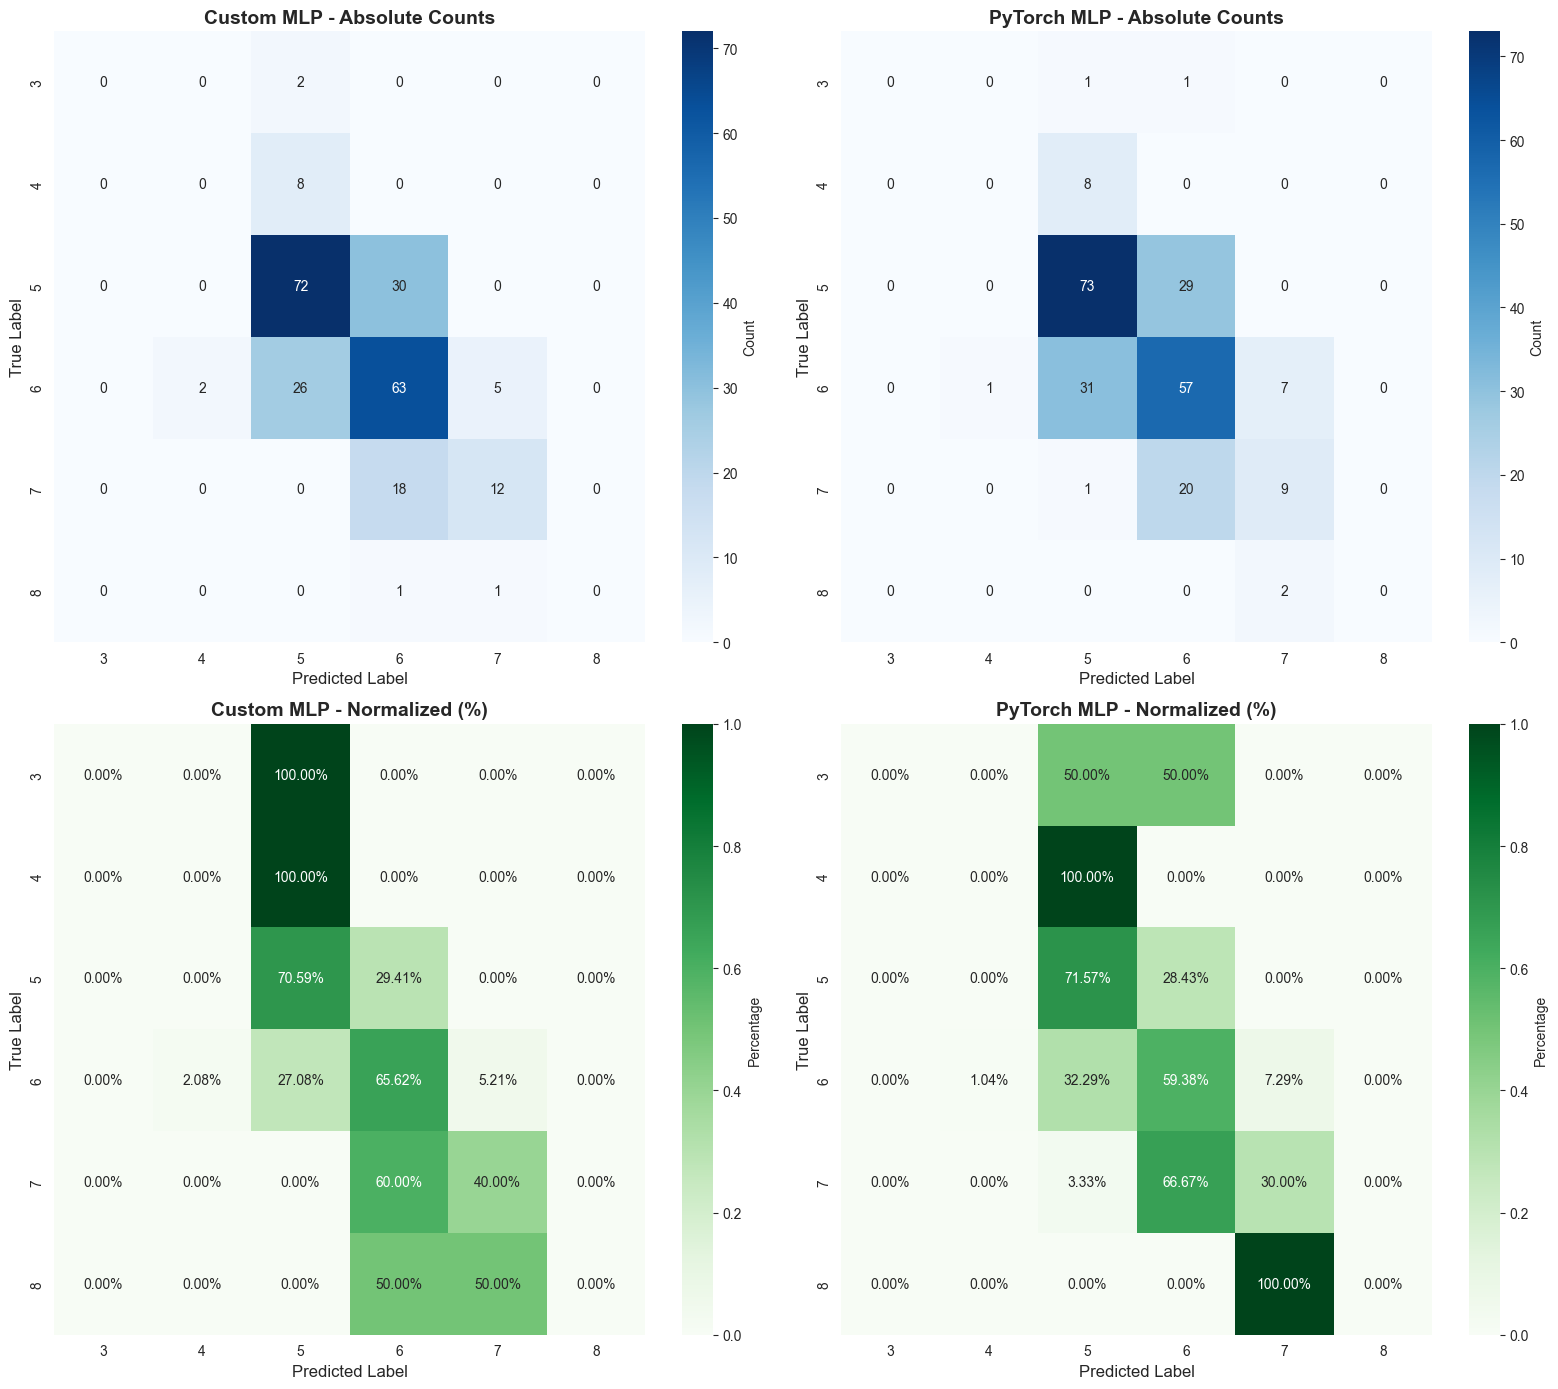

In [40]:
def plot_enhanced_confusion_matrix(y_true, y_pred_custom, y_pred_pt, class_names):
    """Покращена візуалізація confusion matrix"""
    
    cm_c = confusion_matrix(y_true, y_pred_custom)
    cm_p = confusion_matrix(y_true, y_pred_pt)
    
    cm_c_norm = cm_c.astype('float') / cm_c.sum(axis=1)[:, np.newaxis]
    cm_p_norm = cm_p.astype('float') / cm_p.sum(axis=1)[:, np.newaxis]

    fig, axes = plt.subplots(2, 2, figsize=(16, 14))
    
    # Custom MLP - Counts
    sns.heatmap(cm_c, annot=True, fmt='d', cmap='Blues', 
                xticklabels=class_names, yticklabels=class_names,
                ax=axes[0, 0], cbar_kws={'label': 'Count'})
    axes[0, 0].set_title("Custom MLP - Absolute Counts", fontsize=14, fontweight='bold')
    axes[0, 0].set_ylabel('True Label', fontsize=12)
    axes[0, 0].set_xlabel('Predicted Label', fontsize=12)
    
    # PyTorch MLP - Counts
    sns.heatmap(cm_p, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names,
                ax=axes[0, 1], cbar_kws={'label': 'Count'})
    axes[0, 1].set_title("PyTorch MLP - Absolute Counts", fontsize=14, fontweight='bold')
    axes[0, 1].set_ylabel('True Label', fontsize=12)
    axes[0, 1].set_xlabel('Predicted Label', fontsize=12)
    
    # Custom MLP - Normalized
    sns.heatmap(cm_c_norm, annot=True, fmt='.2%', cmap='Greens',
                xticklabels=class_names, yticklabels=class_names,
                ax=axes[1, 0], cbar_kws={'label': 'Percentage'}, vmin=0, vmax=1)
    axes[1, 0].set_title("Custom MLP - Normalized (%)", fontsize=14, fontweight='bold')
    axes[1, 0].set_ylabel('True Label', fontsize=12)
    axes[1, 0].set_xlabel('Predicted Label', fontsize=12)
    
    # PyTorch MLP - Normalized
    sns.heatmap(cm_p_norm, annot=True, fmt='.2%', cmap='Greens',
                xticklabels=class_names, yticklabels=class_names,
                ax=axes[1, 1], cbar_kws={'label': 'Percentage'}, vmin=0, vmax=1)
    axes[1, 1].set_title("PyTorch MLP - Normalized (%)", fontsize=14, fontweight='bold')
    axes[1, 1].set_ylabel('True Label', fontsize=12)
    axes[1, 1].set_xlabel('Predicted Label', fontsize=12)
    
    plt.tight_layout()
    plt.show()
    
plot_enhanced_confusion_matrix(y_test_np, y_pred_custom_np, y_pred_pt_np, class_names)

# 3. ДЕТАЛЬНІ МЕТРИКИ ДЛЯ КОЖНОГО КЛАСУ

In [41]:
print("\n" + "="*70)
print("ДЕТАЛЬНІ МЕТРИКИ ДЛЯ КОЖНОГО КЛАСУ")
print("="*70)

print("\n📊 Custom MLP:")
print("-"*70)
print(classification_report(y_test_np, y_pred_custom_np, target_names=class_names, digits=4))

print("\n📊 PyTorch MLP:")
print("-"*70)
print(classification_report(y_test_np, y_pred_pt_np, target_names=class_names, digits=4))


ДЕТАЛЬНІ МЕТРИКИ ДЛЯ КОЖНОГО КЛАСУ

📊 Custom MLP:
----------------------------------------------------------------------
              precision    recall  f1-score   support

           3     0.0000    0.0000    0.0000         2
           4     0.0000    0.0000    0.0000         8
           5     0.6667    0.7059    0.6857       102
           6     0.5625    0.6562    0.6058        96
           7     0.6667    0.4000    0.5000        30
           8     0.0000    0.0000    0.0000         2

    accuracy                         0.6125       240
   macro avg     0.3160    0.2937    0.2986       240
weighted avg     0.5917    0.6125    0.5962       240


📊 PyTorch MLP:
----------------------------------------------------------------------
              precision    recall  f1-score   support

           3     0.0000    0.0000    0.0000         2
           4     0.0000    0.0000    0.0000         8
           5     0.6404    0.7157    0.6759       102
           6     0.5327    0.59

d:\Uni\MachineLearning\Labs\MachineLearning\ML-FeI-43\env\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\Uni\MachineLearning\Labs\MachineLearning\ML-FeI-43\env\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\Uni\MachineLearning\Labs\MachineLearning\ML-FeI-43\env\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _war

# 4. ROC-КРИВІ ТА AUC ДЛЯ КОЖНОГО КЛАСУ

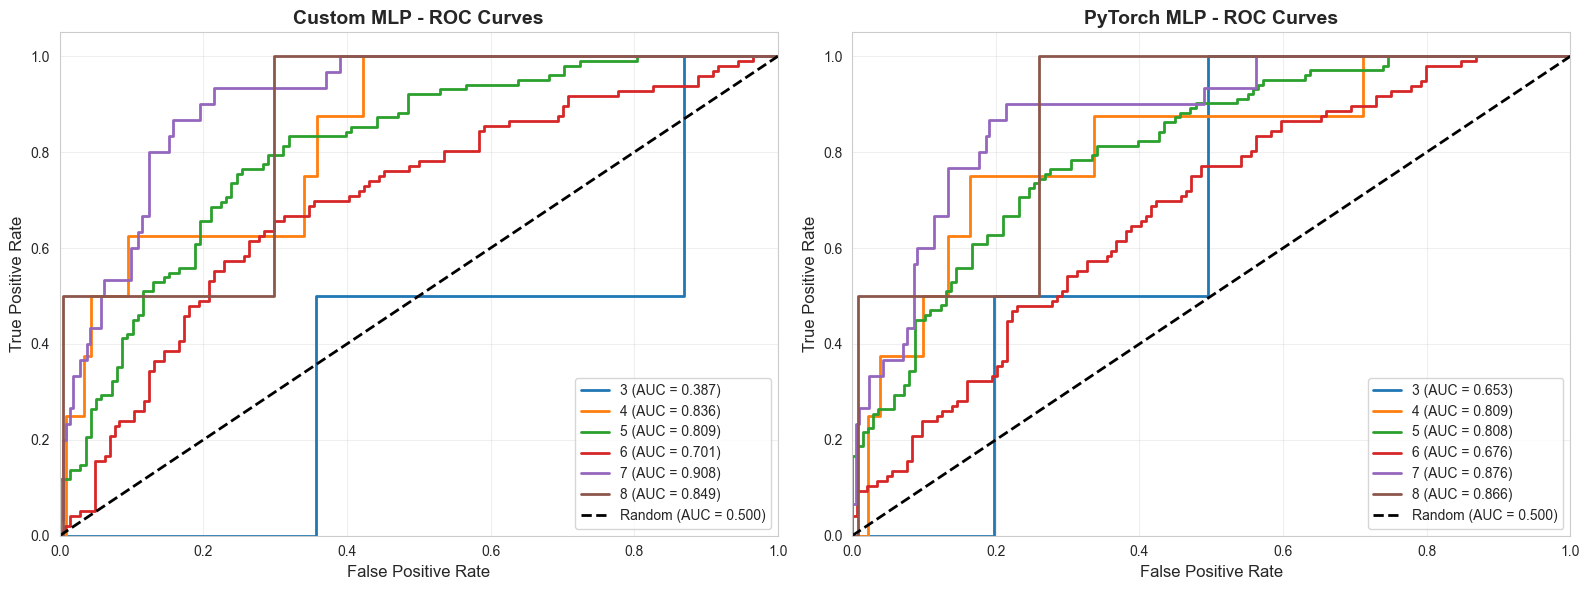


СЕРЕДНІ AUC SCORES
Custom MLP - Macro-averaged AUC:  0.7481
PyTorch MLP - Macro-averaged AUC: 0.7814
Різниця: 0.0333


In [42]:
def plot_roc_curves(y_true, y_pred_custom_proba, y_pred_pt_proba, class_names):
    """Візуалізація ROC-кривих для багатокласової класифікації"""
    
    n_classes = len(class_names)
    
    # Бінаризуємо мітки для One-vs-Rest
    y_true_bin = label_binarize(y_true, classes=range(n_classes))
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # Custom MLP ROC
    for i in range(n_classes):
        fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_pred_custom_proba[:, i])
        roc_auc = auc(fpr, tpr)
        axes[0].plot(fpr, tpr, lw=2, 
                    label=f'{class_names[i]} (AUC = {roc_auc:.3f})')
    
    axes[0].plot([0, 1], [0, 1], 'k--', lw=2, label='Random (AUC = 0.500)')
    axes[0].set_xlim([0.0, 1.0])
    axes[0].set_ylim([0.0, 1.05])
    axes[0].set_xlabel('False Positive Rate', fontsize=12)
    axes[0].set_ylabel('True Positive Rate', fontsize=12)
    axes[0].set_title('Custom MLP - ROC Curves', fontsize=14, fontweight='bold')
    axes[0].legend(loc="lower right", fontsize=10)
    axes[0].grid(True, alpha=0.3)
    
    # PyTorch MLP ROC
    for i in range(n_classes):
        fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_pred_pt_proba[:, i])
        roc_auc = auc(fpr, tpr)
        axes[1].plot(fpr, tpr, lw=2,
                    label=f'{class_names[i]} (AUC = {roc_auc:.3f})')
    
    axes[1].plot([0, 1], [0, 1], 'k--', lw=2, label='Random (AUC = 0.500)')
    axes[1].set_xlim([0.0, 1.0])
    axes[1].set_ylim([0.0, 1.05])
    axes[1].set_xlabel('False Positive Rate', fontsize=12)
    axes[1].set_ylabel('True Positive Rate', fontsize=12)
    axes[1].set_title('PyTorch MLP - ROC Curves', fontsize=14, fontweight='bold')
    axes[1].legend(loc="lower right", fontsize=10)
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Виводимо середні AUC
    custom_auc = roc_auc_score(y_true_bin, y_pred_custom_proba, average='macro')
    pt_auc = roc_auc_score(y_true_bin, y_pred_pt_proba, average='macro')
    
    print("\n" + "="*70)
    print("СЕРЕДНІ AUC SCORES")
    print("="*70)
    print(f"Custom MLP - Macro-averaged AUC:  {custom_auc:.4f}")
    print(f"PyTorch MLP - Macro-averaged AUC: {pt_auc:.4f}")
    print(f"Різниця: {abs(custom_auc - pt_auc):.4f}")

plot_roc_curves(y_test_np, y_pred_custom_proba_np, y_pred_pt_proba_np, class_names)

# 5. ПОРІВНЯННЯ ПОМИЛОК МІЖ МОДЕЛЯМИ


ПОРІВНЯЛЬНИЙ АНАЛІЗ ПОМИЛОК
✅ Обидві моделі правильно:         128 (53.33%)
❌ Обидві моделі неправильно:        82 (34.17%)
🔵 Тільки Custom правильно:          19 (7.92%)
🟠 Тільки PyTorch правильно:         11 (4.58%)


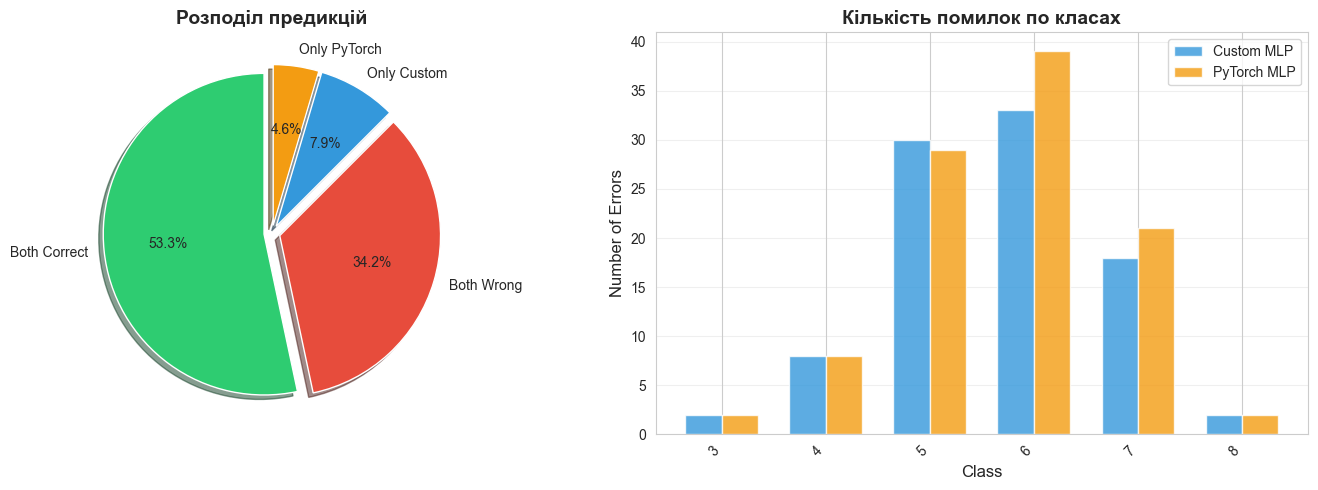

In [43]:
def analyze_error_comparison(y_true, y_pred_custom, y_pred_pt, class_names):
    """Аналіз помилок: де моделі помиляються по-різному"""
    
    custom_correct = (y_pred_custom == y_true)
    pt_correct = (y_pred_pt == y_true)
    
    both_correct = np.sum(custom_correct & pt_correct)
    both_wrong = np.sum(~custom_correct & ~pt_correct)
    only_custom_correct = np.sum(custom_correct & ~pt_correct)
    only_pt_correct = np.sum(~custom_correct & pt_correct)
    
    print("\n" + "="*70)
    print("ПОРІВНЯЛЬНИЙ АНАЛІЗ ПОМИЛОК")
    print("="*70)
    print(f"✅ Обидві моделі правильно:        {both_correct:4d} ({both_correct/len(y_true)*100:.2f}%)")
    print(f"❌ Обидві моделі неправильно:      {both_wrong:4d} ({both_wrong/len(y_true)*100:.2f}%)")
    print(f"🔵 Тільки Custom правильно:        {only_custom_correct:4d} ({only_custom_correct/len(y_true)*100:.2f}%)")
    print(f"🟠 Тільки PyTorch правильно:       {only_pt_correct:4d} ({only_pt_correct/len(y_true)*100:.2f}%)")
    
    # Візуалізація
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Pie chart
    labels = ['Both Correct', 'Both Wrong', 'Only Custom', 'Only PyTorch']
    sizes = [both_correct, both_wrong, only_custom_correct, only_pt_correct]
    colors = ['#2ecc71', '#e74c3c', '#3498db', '#f39c12']
    explode = (0.05, 0.05, 0.05, 0.05)
    
    axes[0].pie(sizes, explode=explode, labels=labels, colors=colors,
                autopct='%1.1f%%', shadow=True, startangle=90)
    axes[0].set_title('Розподіл предикцій', fontsize=14, fontweight='bold')
    
    # Bar chart - помилки по класах
    custom_errors_per_class = []
    pt_errors_per_class = []
    
    for i in range(len(class_names)):
        mask = (y_true == i)
        custom_errors_per_class.append(np.sum(~custom_correct[mask]))
        pt_errors_per_class.append(np.sum(~pt_correct[mask]))
    
    x = np.arange(len(class_names))
    width = 0.35
    
    axes[1].bar(x - width/2, custom_errors_per_class, width, label='Custom MLP', 
                color='#3498db', alpha=0.8)
    axes[1].bar(x + width/2, pt_errors_per_class, width, label='PyTorch MLP',
                color='#f39c12', alpha=0.8)
    
    axes[1].set_xlabel('Class', fontsize=12)
    axes[1].set_ylabel('Number of Errors', fontsize=12)
    axes[1].set_title('Кількість помилок по класах', fontsize=14, fontweight='bold')
    axes[1].set_xticks(x)
    axes[1].set_xticklabels(class_names, rotation=45, ha='right')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.show()
    
    return custom_correct, pt_correct

custom_correct, pt_correct = analyze_error_comparison(
    y_test_np, y_pred_custom_np, y_pred_pt_np, class_names
)

# 6. СТАТИСТИЧНИЙ ТЕСТ РІЗНИЦІ В ПРОДУКТИВНОСТІ

In [44]:
def statistical_comparison(y_true, y_pred_custom, y_pred_pt):
    """McNemar's test для порівняння двох класифікаторів"""
    
    custom_correct = (y_pred_custom == y_true)
    pt_correct = (y_pred_pt == y_true)
    
    # Contingency table для McNemar's test
    n00 = np.sum(~custom_correct & ~pt_correct)  # Обидві помилилися
    n01 = np.sum(~custom_correct & pt_correct)   # Custom помилився, PyTorch ні
    n10 = np.sum(custom_correct & ~pt_correct)   # PyTorch помився, Custom ні
    n11 = np.sum(custom_correct & pt_correct)    # Обидві правильні
    
    # McNemar's test
    if n01 + n10 > 0:
        statistic = (abs(n01 - n10) - 1)**2 / (n01 + n10)
        p_value = 1 - stats.chi2.cdf(statistic, 1)
    else:
        statistic = 0
        p_value = 1.0
    
    print("\n" + "="*70)
    print("СТАТИСТИЧНИЙ ТЕСТ (McNEMAR'S TEST)")
    print("="*70)
    print("\nContingency Table:")
    print(f"                    PyTorch Correct  PyTorch Wrong")
    print(f"Custom Correct           {n11:4d}           {n10:4d}")
    print(f"Custom Wrong             {n01:4d}           {n00:4d}")
    print(f"\nMcNemar's χ² statistic: {statistic:.4f}")
    print(f"p-value: {p_value:.4f}")
    
    if p_value < 0.05:
        print(f"\n📊 Висновок: Різниця статистично значуща (p < 0.05)")
        if n01 > n10:
            print("   PyTorch MLP показує кращі результати")
        else:
            print("   Custom MLP показує кращі результати")
    else:
        print(f"\n📊 Висновок: Різниця статистично незначуща (p >= 0.05)")
        print("   Моделі показують схожу продуктивність")

statistical_comparison(y_test_np, y_pred_custom_np, y_pred_pt_np)


СТАТИСТИЧНИЙ ТЕСТ (McNEMAR'S TEST)

Contingency Table:
                    PyTorch Correct  PyTorch Wrong
Custom Correct            128             19
Custom Wrong               11             82

McNemar's χ² statistic: 1.6333
p-value: 0.2012

📊 Висновок: Різниця статистично незначуща (p >= 0.05)
   Моделі показують схожу продуктивність


# 7. ВІЗУАЛІЗАЦІЯ НЕПРАВИЛЬНО КЛАСИФІКОВАНИХ ПРИКЛАДІВ

In [45]:
def visualize_misclassified_samples(X_test, y_true, y_pred_custom, y_pred_pt, 
                                   class_names, n_samples=10):
    """Візуалізація найцікавіших помилок моделей"""
    
    custom_correct = (y_pred_custom == y_true)
    pt_correct = (y_pred_pt == y_true)
    
    # Знаходимо різні типи помилок
    both_wrong_idx = np.where(~custom_correct & ~pt_correct)[0]
    only_custom_wrong_idx = np.where(~custom_correct & pt_correct)[0]
    only_pt_wrong_idx = np.where(custom_correct & ~pt_correct)[0]
    
    print("\n" + "="*70)
    print("ПРИКЛАДИ НЕПРАВИЛЬНИХ КЛАСИФІКАЦІЙ")
    print("="*70)
    
    # Візуалізуємо випадки, де обидві моделі помилилися
    if len(both_wrong_idx) > 0:
        n_show = min(n_samples, len(both_wrong_idx))
        selected_idx = np.random.choice(both_wrong_idx, n_show, replace=False)
        
        print(f"\n❌ Обидві моделі помилились ({n_show} прикладів):")
        print("-"*70)
        
        for idx in selected_idx:
            true_label = class_names[y_true[idx]]
            custom_pred = class_names[y_pred_custom[idx]]
            pt_pred = class_names[y_pred_pt[idx]]
            
            print(f"Sample {idx}:")
            print(f"  True: {true_label}")
            print(f"  Custom predicted: {custom_pred}")
            print(f"  PyTorch predicted: {pt_pred}")
            print()
    
    # Випадки, де тільки Custom помилився
    if len(only_custom_wrong_idx) > 0:
        n_show = min(5, len(only_custom_wrong_idx))
        selected_idx = np.random.choice(only_custom_wrong_idx, n_show, replace=False)
        
        print(f"\n🔵 Тільки Custom помилився ({n_show} прикладів):")
        print("-"*70)
        
        for idx in selected_idx:
            true_label = class_names[y_true[idx]]
            custom_pred = class_names[y_pred_custom[idx]]
            pt_pred = class_names[y_pred_pt[idx]]
            
            print(f"Sample {idx}:")
            print(f"  True: {true_label}")
            print(f"  Custom predicted: {custom_pred} ❌")
            print(f"  PyTorch predicted: {pt_pred} ✓")
            print()
    
    # Випадки, де тільки PyTorch помилився
    if len(only_pt_wrong_idx) > 0:
        n_show = min(5, len(only_pt_wrong_idx))
        selected_idx = np.random.choice(only_pt_wrong_idx, n_show, replace=False)
        
        print(f"\n🟠 Тільки PyTorch помилився ({n_show} прикладів):")
        print("-"*70)
        
        for idx in selected_idx:
            true_label = class_names[y_true[idx]]
            custom_pred = class_names[y_pred_custom[idx]]
            pt_pred = class_names[y_pred_pt[idx]]
            
            print(f"Sample {idx}:")
            print(f"  True: {true_label}")
            print(f"  Custom predicted: {custom_pred} ✓")
            print(f"  PyTorch predicted: {pt_pred} ❌")
            print()

visualize_misclassified_samples(
    X_test, y_test_np, y_pred_custom_np, y_pred_pt_np, 
    class_names, n_samples=10
)


ПРИКЛАДИ НЕПРАВИЛЬНИХ КЛАСИФІКАЦІЙ

❌ Обидві моделі помилились (10 прикладів):
----------------------------------------------------------------------
Sample 78:
  True: 5
  Custom predicted: 6
  PyTorch predicted: 6

Sample 144:
  True: 4
  Custom predicted: 5
  PyTorch predicted: 5

Sample 137:
  True: 7
  Custom predicted: 6
  PyTorch predicted: 6

Sample 196:
  True: 5
  Custom predicted: 6
  PyTorch predicted: 6

Sample 86:
  True: 7
  Custom predicted: 6
  PyTorch predicted: 6

Sample 35:
  True: 5
  Custom predicted: 6
  PyTorch predicted: 6

Sample 209:
  True: 5
  Custom predicted: 6
  PyTorch predicted: 6

Sample 166:
  True: 4
  Custom predicted: 5
  PyTorch predicted: 5

Sample 29:
  True: 5
  Custom predicted: 6
  PyTorch predicted: 6

Sample 197:
  True: 5
  Custom predicted: 6
  PyTorch predicted: 6


🔵 Тільки Custom помилився (5 прикладів):
----------------------------------------------------------------------
Sample 25:
  True: 5
  Custom predicted: 6 ❌
  PyTorch predi

# 8. CONFIDENCE ANALYSIS (АНАЛІЗ ВПЕВНЕНОСТІ МОДЕЛЕЙ)


Аналіз впевненості моделей...

АНАЛІЗ ВПЕВНЕНОСТІ МОДЕЛЕЙ

Custom MLP:
  Середня впевненість (правильні): 0.6811
  Середня впевненість (неправильні): 0.6061

PyTorch MLP:
  Середня впевненість (правильні): 0.7177
  Середня впевненість (неправильні): 0.6237


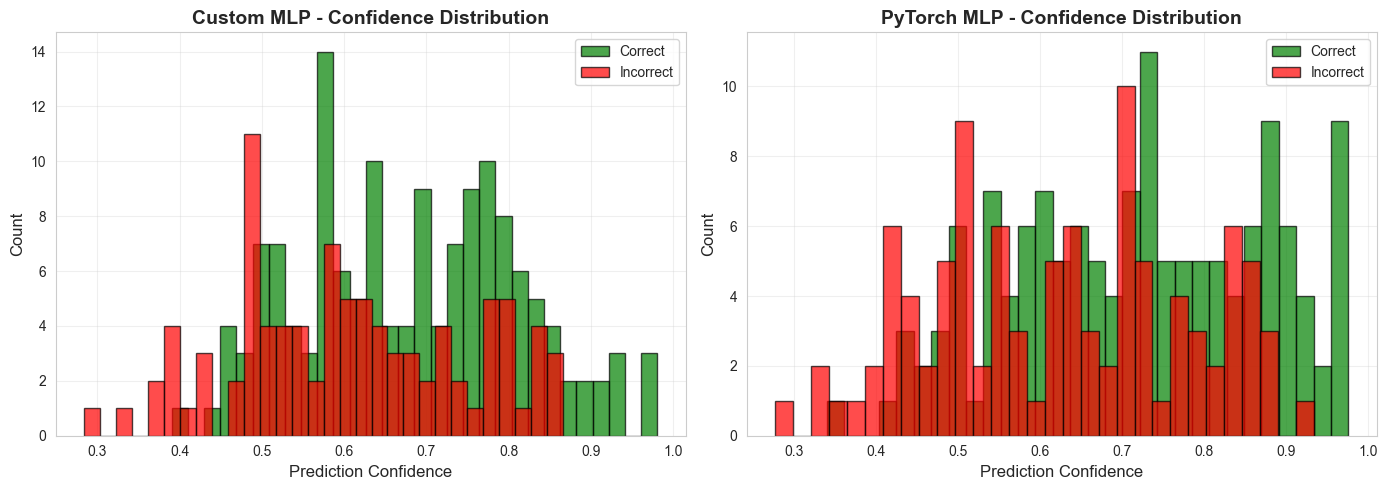

In [47]:
def analyze_prediction_confidence(y_pred_custom_proba, y_pred_pt_proba, 
                                 y_true, y_pred_custom, y_pred_pt):
    """Аналіз впевненості моделей у своїх предикціях"""
    
    custom_confidence = np.max(y_pred_custom_proba, axis=1)
    pt_confidence = np.max(y_pred_pt_proba, axis=1)
    
    custom_correct = (y_pred_custom == y_true)
    pt_correct = (y_pred_pt == y_true)
    
    print("\n" + "="*70)
    print("АНАЛІЗ ВПЕВНЕНОСТІ МОДЕЛЕЙ")
    print("="*70)
    
    print(f"\nCustom MLP:")
    print(f"  Середня впевненість (правильні): {custom_confidence[custom_correct].mean():.4f}")
    print(f"  Середня впевненість (неправильні): {custom_confidence[~custom_correct].mean():.4f}")
    
    print(f"\nPyTorch MLP:")
    print(f"  Середня впевненість (правильні): {pt_confidence[pt_correct].mean():.4f}")
    print(f"  Середня впевненість (неправильні): {pt_confidence[~pt_correct].mean():.4f}")
    
    # Візуалізація
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Custom MLP
    axes[0].hist(custom_confidence[custom_correct], bins=30, alpha=0.7, 
                label='Correct', color='green', edgecolor='black')
    axes[0].hist(custom_confidence[~custom_correct], bins=30, alpha=0.7,
                label='Incorrect', color='red', edgecolor='black')
    axes[0].set_xlabel('Prediction Confidence', fontsize=12)
    axes[0].set_ylabel('Count', fontsize=12)
    axes[0].set_title('Custom MLP - Confidence Distribution', fontsize=14, fontweight='bold')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # PyTorch MLP
    axes[1].hist(pt_confidence[pt_correct], bins=30, alpha=0.7,
                label='Correct', color='green', edgecolor='black')
    axes[1].hist(pt_confidence[~pt_correct], bins=30, alpha=0.7,
                label='Incorrect', color='red', edgecolor='black')
    axes[1].set_xlabel('Prediction Confidence', fontsize=12)
    axes[1].set_ylabel('Count', fontsize=12)
    axes[1].set_title('PyTorch MLP - Confidence Distribution', fontsize=14, fontweight='bold')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

print("\nАналіз впевненості моделей...")
analyze_prediction_confidence(
    y_pred_custom_proba_np, y_pred_pt_proba_np,
    y_test_np, y_pred_custom_np, y_pred_pt_np
)